In [5]:
import pandas as pd
import numpy as np
import nibabel as nib
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl


In [6]:
import matplotlib.pyplot as plt
from neuroaging.visualization import (
    configure_plotting,
    savefig_nice,
    COL_RAW,
    COL_WEIGHTED,
    COL_REF,
    COL_CENSUS,
    CMAP_RAW,
    CMAP_WEIGHTED,
)

configure_plotting()


In [7]:
ATLAS = "schaefer2018tian2020_400_7"
region_col = "index"
# Load important files
# DATA_DIR = Path("/media/groot/Minerva/phd/neuroaging/data")
DATA_DIR = Path("/media/storage/phd/neuroaging/data")

# Output directory for figures
# OUTPUT_DIR = Path("/media/groot/Minerva/phd/neuroaging/figures/revision/fig2")
OUTPUT_DIR = Path("/media/storage/phd/neuroaging/figures/revision/fig2")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load the data
parcels = pd.read_csv(DATA_DIR / "external" / "atlases" / ATLAS / "parcels.csv", index_col=0)
nifti = DATA_DIR / "external" / "atlases" / ATLAS / "atlas.nii.gz"
nifti_matlab = DATA_DIR / "external" / "atlases" / ATLAS / "atlas_matlab.nii"

In [8]:
metric = "adc"
distribution_metric = "qfmean"
data = pd.read_csv(DATA_DIR / "processed" / f"{metric}.csv", index_col=0).reset_index(drop=True)

data["age_squared"] = data["age_at_scan"] ** 2
data["sex"] = data["sex"].map({"M": 0, "F": 1})

/tmp/ipykernel_2621032/3554660329.py:3: DtypeWarning: Columns (16,22,23,26,32,36,37,38,39,40,42,43,44,45,50,51,52,53,54,55,57,71,73,74,79,80,81,82,89,90,91,101) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(DATA_DIR / "processed" / f"{metric}.csv", index_col=0).reset_index(drop=True)


In [9]:
metric_col = "volume" if metric == "gm_vol" else distribution_metric

In [10]:
israel_population = pd.read_csv(DATA_DIR / "processed" / "israel_population.csv")

In [11]:
from neuroaging.stats import compute_joint_poststrat_weights

In [12]:
# assign weights
data["weight"], _ = compute_joint_poststrat_weights(
    data,
    israel_population,
    age_col="age_at_scan",
    sex_col="sex",
    return_bin_table=True,
    cap=10  # Optional: prevents any single female/male from having too much influence
)

In [13]:
from neuroaging.modeling.regional import fit_regional_models, apply_fdr_correction

# Centering option
CENTER_VARIABLES = True

if CENTER_VARIABLES:
    age_col = "age_c"
else:
    age_col = "age_at_scan"
    
covariates = [age_col, "sex"]
if metric == "gm_vol":
    covariates += ["tiv"]
models = fit_regional_models(
    data,
    parcels,
    region_col=region_col,
    metric_col=metric_col,
    covariates=covariates,
    center_variables=True
)

apply_fdr_correction(models)

In [14]:
import numpy as np
import pandas as pd
import nibabel as nb
from nilearn import surface, datasets
from surfplot import Plot
from matplotlib.colors import TwoSlopeNorm  # nice diverging colours
from neuromaps.datasets import fetch_fslr
from brainspace.datasets import load_parcellation


atlas_img = nib.load(nifti_matlab)

# ---------------------------------------------------------------------
# 2.  FETCH A STANDARD SURFACE  (fsaverage5 = 10k vertices per hemi)
# ---------------------------------------------------------------------
surfaces = fetch_fslr()
lh, rh = surfaces["inflated"]


# ---------------------------------------------------------------------
# 3.  SAMPLE ATLAS VOXELS → SURFACE  (nearest-neighbour so labels stay int)
# ---------------------------------------------------------------------
# add schaefer parcellation (no color bar needed)
lh_parc, rh_parc = load_parcellation("schaefer")

In [24]:
# models.comparison.copy()
m = models.comparison.copy()
m[(m["pvalue_corrected"] < 0.05) & (m["delta_AIC"] > -15)]

,index,name,base_name,Label Name,network,component,hemisphere,f,pvalue,log(f),n,AIC(lin),AIC(quad),delta_AIC,BIC(lin),BIC(quad),delta_BIC,pvalue_corrected
6,7,7Networks_LH_Vis_7,7networks_lh_vis,7Networks_LH_Vis,visual,visual,L,15.517586,0.000084,2.741974,2796.0,-42816.362001,-42829.858794,-13.496793,-42798.554166,-42806.115013,-7.560848,0.000100
14,15,7Networks_LH_Vis_15,7networks_lh_vis,7Networks_LH_Vis,visual,visual,L,5.552913,0.018519,1.714323,2796.0,-42831.640776,-42835.196122,-3.555345,-42813.832941,-42811.452341,2.380600,0.020759
28,29,7Networks_LH_Vis_29,7networks_lh_vis,7Networks_LH_Vis,visual,visual,L,11.963933,0.000551,2.481897,2796.0,-41959.285310,-41969.240787,-9.955476,-41941.477475,-41945.497006,-4.019531,0.000644
43,44,7Networks_LH_SomMot_13,7networks_lh_sommot,7Networks_LH_SomMot,somatomotor,somatomotor,L,5.534617,0.018713,1.711022,2796.0,-43432.838592,-43436.375652,-3.537060,-43415.030757,-43412.631872,2.398885,0.020925
50,51,7Networks_LH_SomMot_20,7networks_lh_sommot,7Networks_LH_SomMot,somatomotor,somatomotor,L,4.296886,0.038274,1.457890,2796.0,-39740.311375,-39742.611109,-2.299734,-39722.503540,-39718.867329,3.636211,0.041972
62,63,7Networks_LH_SomMot_32,7networks_lh_sommot,7Networks_LH_SomMot,somatomotor,somatomotor,L,9.920301,0.001652,2.294583,2796.0,-40769.258553,-40777.175460,-7.916906,-40751.450718,-40753.431679,-1.980961,0.001904
63,64,7Networks_LH_SomMot_33,7networks_lh_sommot,7Networks_LH_SomMot,somatomotor,somatomotor,L,7.135245,0.007602,1.965047,2796.0,-43536.332932,-43541.469284,-5.136352,-43518.525097,-43517.725504,0.799593,0.008607
78,79,7Networks_LH_DorsAttn_Post_11,7networks_lh_dorsattn_post,7Networks_LH_DorsAttn_Post,dorsal attention,posterior,L,9.818651,0.001745,2.284284,2796.0,-39610.657665,-39618.473133,-7.815469,-39592.849829,-39594.729353,-1.879523,0.002006
79,80,7Networks_LH_DorsAttn_Post_12,7networks_lh_dorsattn_post,7Networks_LH_DorsAttn_Post,dorsal attention,posterior,L,6.208104,0.012774,1.825856,2796.0,-39706.089226,-39710.299322,-4.210097,-39688.281390,-39686.555542,1.725848,0.014427
81,82,7Networks_LH_DorsAttn_Post_14,7networks_lh_dorsattn_post,7Networks_LH_DorsAttn_Post,dorsal attention,posterior,L,5.463957,0.019483,1.698173,2796.0,-40369.076418,-40372.542856,-3.466438,-40351.268583,-40348.799076,2.469507,0.021627


In [16]:
# ---------------------------------------------------------------------
# 4.  MAP REGION IDs → METRIC VALUES
#     vertices with label 0 (background) → NaN so they render transparent
# ---------------------------------------------------------------------
p_threshold = 0.05
value_threshold = 0

value_map = {}
value_map_subcortex = {"region": [], "value": [], "Hemisphere": []}

# R2 visualization
vis_df = models.quadratic.copy()
value_column = "r2_adj"
p_column = "pvalue_corrected"

# F visualization
# vis_df = models.comparison.copy()
# value_column = "log(f)"
# p_column = "pvalue_corrected"


value_map_lh = {}  # New: separate map for left hemisphere
value_map_rh = {}  # New: separate map for right hemisphere

for i, row in vis_df.iterrows():
    label = row[region_col]
    hemi_row = row["hemisphere"]  # Get hemisphere from your DataFrame row

    # Apply thresholds
    if (row[p_column] < p_threshold) and (np.abs(row[value_column]) > value_threshold):
        value = row[value_column]
    else:
        value = np.nan  # Set to NaN if not significant or below value_threshold
    if value_column == "log(f)":
        if vis_df.loc[i, "delta_BIC"] > -15:
            value = np.nan

    # Populate the correct hemisphere's value_map
    # Assuming your labels are global and you use the 'hemisphere' column to distinguish
    # If your Schaefer labels are already separated by hemi (e.g., 1-200 for LH, 201-400 for RH)
    # then you might only need to check the label range and not the 'hemisphere' column.
    # For Schaefer, the labels usually run 1-N for LH and N+1 - 2N for RH
    if "schaefer" in ATLAS:
        if label > int(ATLAS.split("_")[1]):
            value_map_subcortex["region"].append(label)
            value_map_subcortex["value"].append(value)
            value_map_subcortex["Hemisphere"].append(row["hemisphere"])
        else:
            if hemi_row == "L":
                value_map_lh[label] = value
            elif hemi_row == "R":
                value_map_rh[label] = value
        # Subcortex handling would go here if you were preparing for separate subcortical visualization
        # else: # This implies it's subcortical or other non-surface region
        #     value_map_subcortex["region"].append(label)
        #     value_map_subcortex["value"].append(value)
        #     value_map_subcortex["Hemisphere"].append(row["hemisphere"])

# Vectorize mapping for left and right hemispheres separately
vec_lh = np.vectorize(lambda x: value_map_lh.get(x, np.nan))
data_lh_mapped = vec_lh(lh_parc)  # Apply LH map to LH parcellation
vec_rh = np.vectorize(lambda x: value_map_rh.get(x, np.nan))
data_rh_mapped = vec_rh(rh_parc)  # Apply RH map to RH parcellation

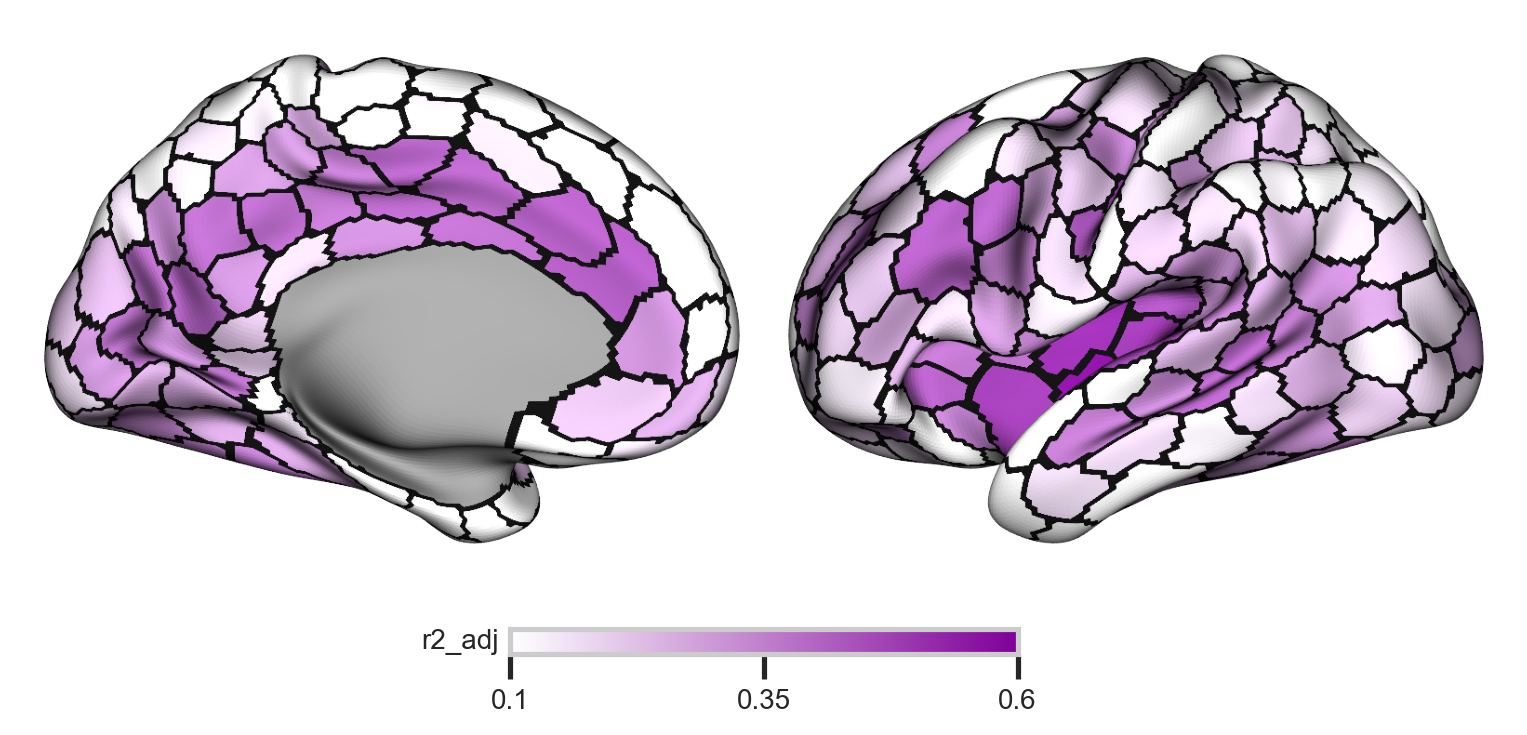

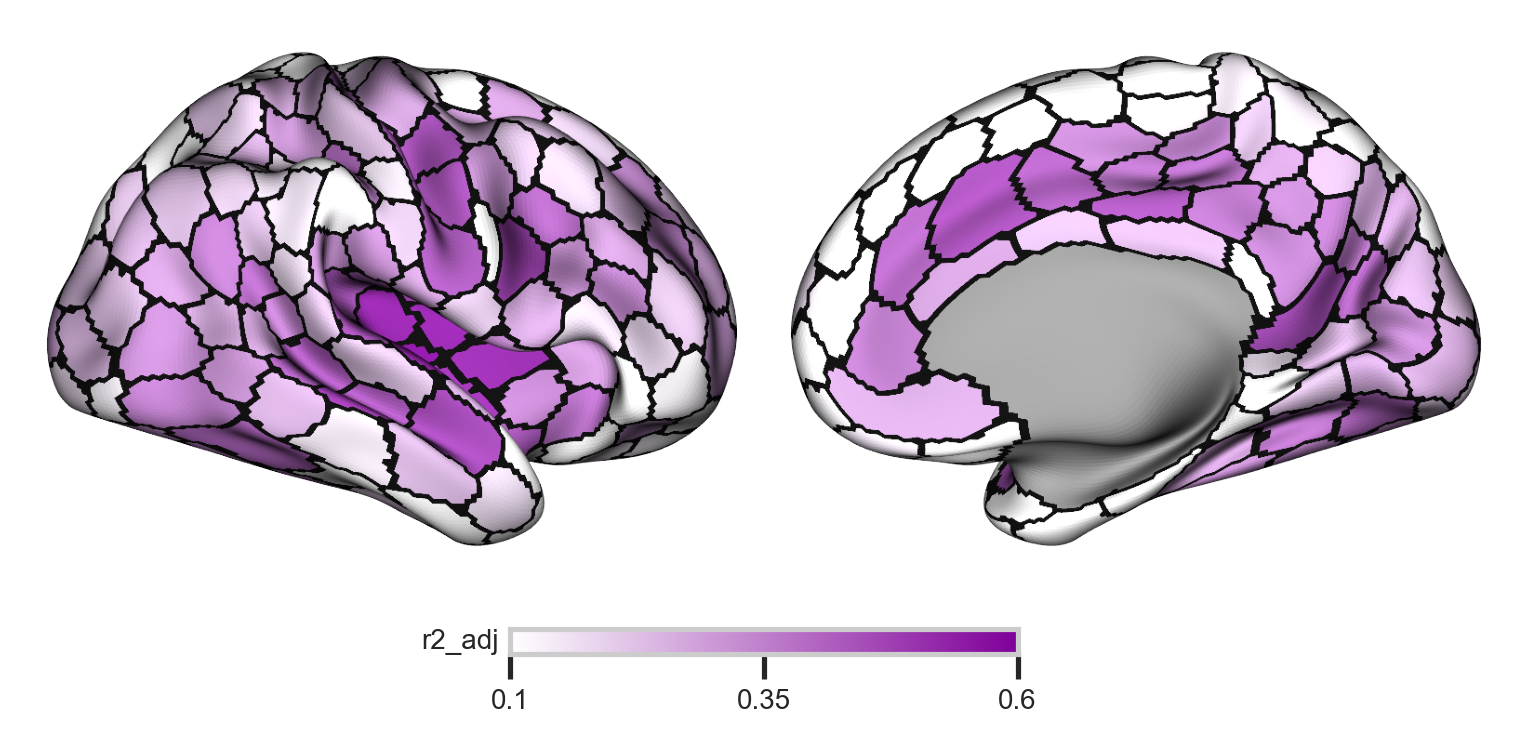

In [17]:
vmin = 1 if "(f)" in value_column else 0.1
vmax = 7 if "(f)" in value_column else 0.6
# vmin = -vis_df[value_column].abs().quantile(0.5)
# vmax = vis_df[value_column].abs().quantile(0.5)
# vmax = 7

cmap = "Reds" if "(f)" in value_column else CMAP_WEIGHTED

# Corrected loop for plotting each hemisphere independently
for hemi_key, hemi_surf_data, mapped_data, parcellation_data in zip(
    ["left", "right"],  # The key for surfplot's dictionary
    [lh, rh],  # The surface object for the current hemisphere
    [data_lh_mapped, data_rh_mapped],  # The mapped data for the current hemisphere
    [lh_parc, rh_parc],  # The parcellation for the current hemisphere
):
    # ---------------------------------------------------------------------
    # 5.  BUILD THE PLOT
    # ---------------------------------------------------------------------
    pref_surf = {
        "surf_lh": hemi_surf_data if hemi_key == "left" else None,
        "surf_rh": hemi_surf_data if hemi_key == "right" else None,
    }

    views = ["lateral", "medial"] if hemi_key == "right" else ["medial", "lateral"]
    p = Plot(
        **pref_surf,  # Unpack the surface dictionary
        views=views,  # Show both medial and lateral for this hemi
        size=(800, 300),  # px; change as needed
        zoom=1.6,
        layout="row",  # For a single hemisphere, row is fine
        mirror_views=False,  # Set to False, as we are plotting one hemi at a time
    )

    # ---- main data layer -------------------------------------------------
    # Pass only the data for the current hemisphere
    # The dictionary now contains only one key-value pair for the current hemisphere
    p.add_layer(
        {hemi_key: mapped_data},
        # cmap="Purples",
        cmap=cmap,
        # cmap="coolwarm",
        color_range=(vmin, vmax),  # Use symmetric range
        # norm=norm,  # Apply the symmetric normalization
        cbar_label=value_column,
        cbar=True,  # Ensure colorbar is shown for each plot if desired, or handle globally
    )
    # ---- outline layer ---------------------------------------------------
    p.add_layer({hemi_key: parcellation_data}, cmap="gray", as_outline=True, cbar=False)

    fig = p.build(
        # cbar_kws=dict(location="bottom", decimals=2, shrink=0.6)
    )  # Added cbar_kws for better cbar display
    # save figure
    savefig_nice(
        fig, OUTPUT_DIR.resolve() / f"fig2_{metric}_{hemi_key}_{value_column}.png", dpi=400
    )

In [18]:
from subcortex_visualization.plotting import plot_subcortical_data

subcort_df = pd.DataFrame(value_map_subcortex)
if "schaefer" in ATLAS:
    subcort_df["region"] = subcort_df["region"] - int(ATLAS.split("_")[1])


for hemi in ["L", "R"]:

    fig = plot_subcortical_data(
        subcort_df,
        atlas="Melbourne_S3",
        show_legend=True,
        hemisphere=hemi,
        # cmap="coolwarm",
        cmap=cmap,
        line_color="black",
        line_thickness=2,
        vmin=vmin,
        vmax=vmax,
        show_figure=False,
    )

    # save figure
    savefig_nice(fig, OUTPUT_DIR / f"fig2_subcort_{metric}_{hemi}_{value_column}.png", dpi=400)

ValueError: You are trying to merge on object and int64 columns for key 'region'. If you wish to proceed you should use pd.concat

In [ ]:
example_rois = {
    413: {"name": "R. Putamen", "component": "Basal Ganglia"},
    447: {"name": "L. Amygdala", "component": "Limbic System"},
    168: {"name": "L. PFC", "component": "Prefrontal Cortex"},
    179: {"name": "L. PFC", "component": "Prefrontal Cortex"},
    50: {"name": "L. Postcentral", "component": "Somatomotor"},
    258: {"name": "R. Precentral", "component": "Somatomotor"},
    405: {"name": "R. Hippocampus", "component": "Limbic System"},
    234: {"name": "Insula", "component": "Insular Cortex"},
    263: {"name": "L. Precentral", "component": "Somatomotor"},
    312: {"name": "Precuneus", "component": "Parietal Cortex"},
    267: {"name": "R. Precentral", "component": "Somatomotor"},
    67: {"name": "L. Precentral", "component": "Somatomotor"},
}

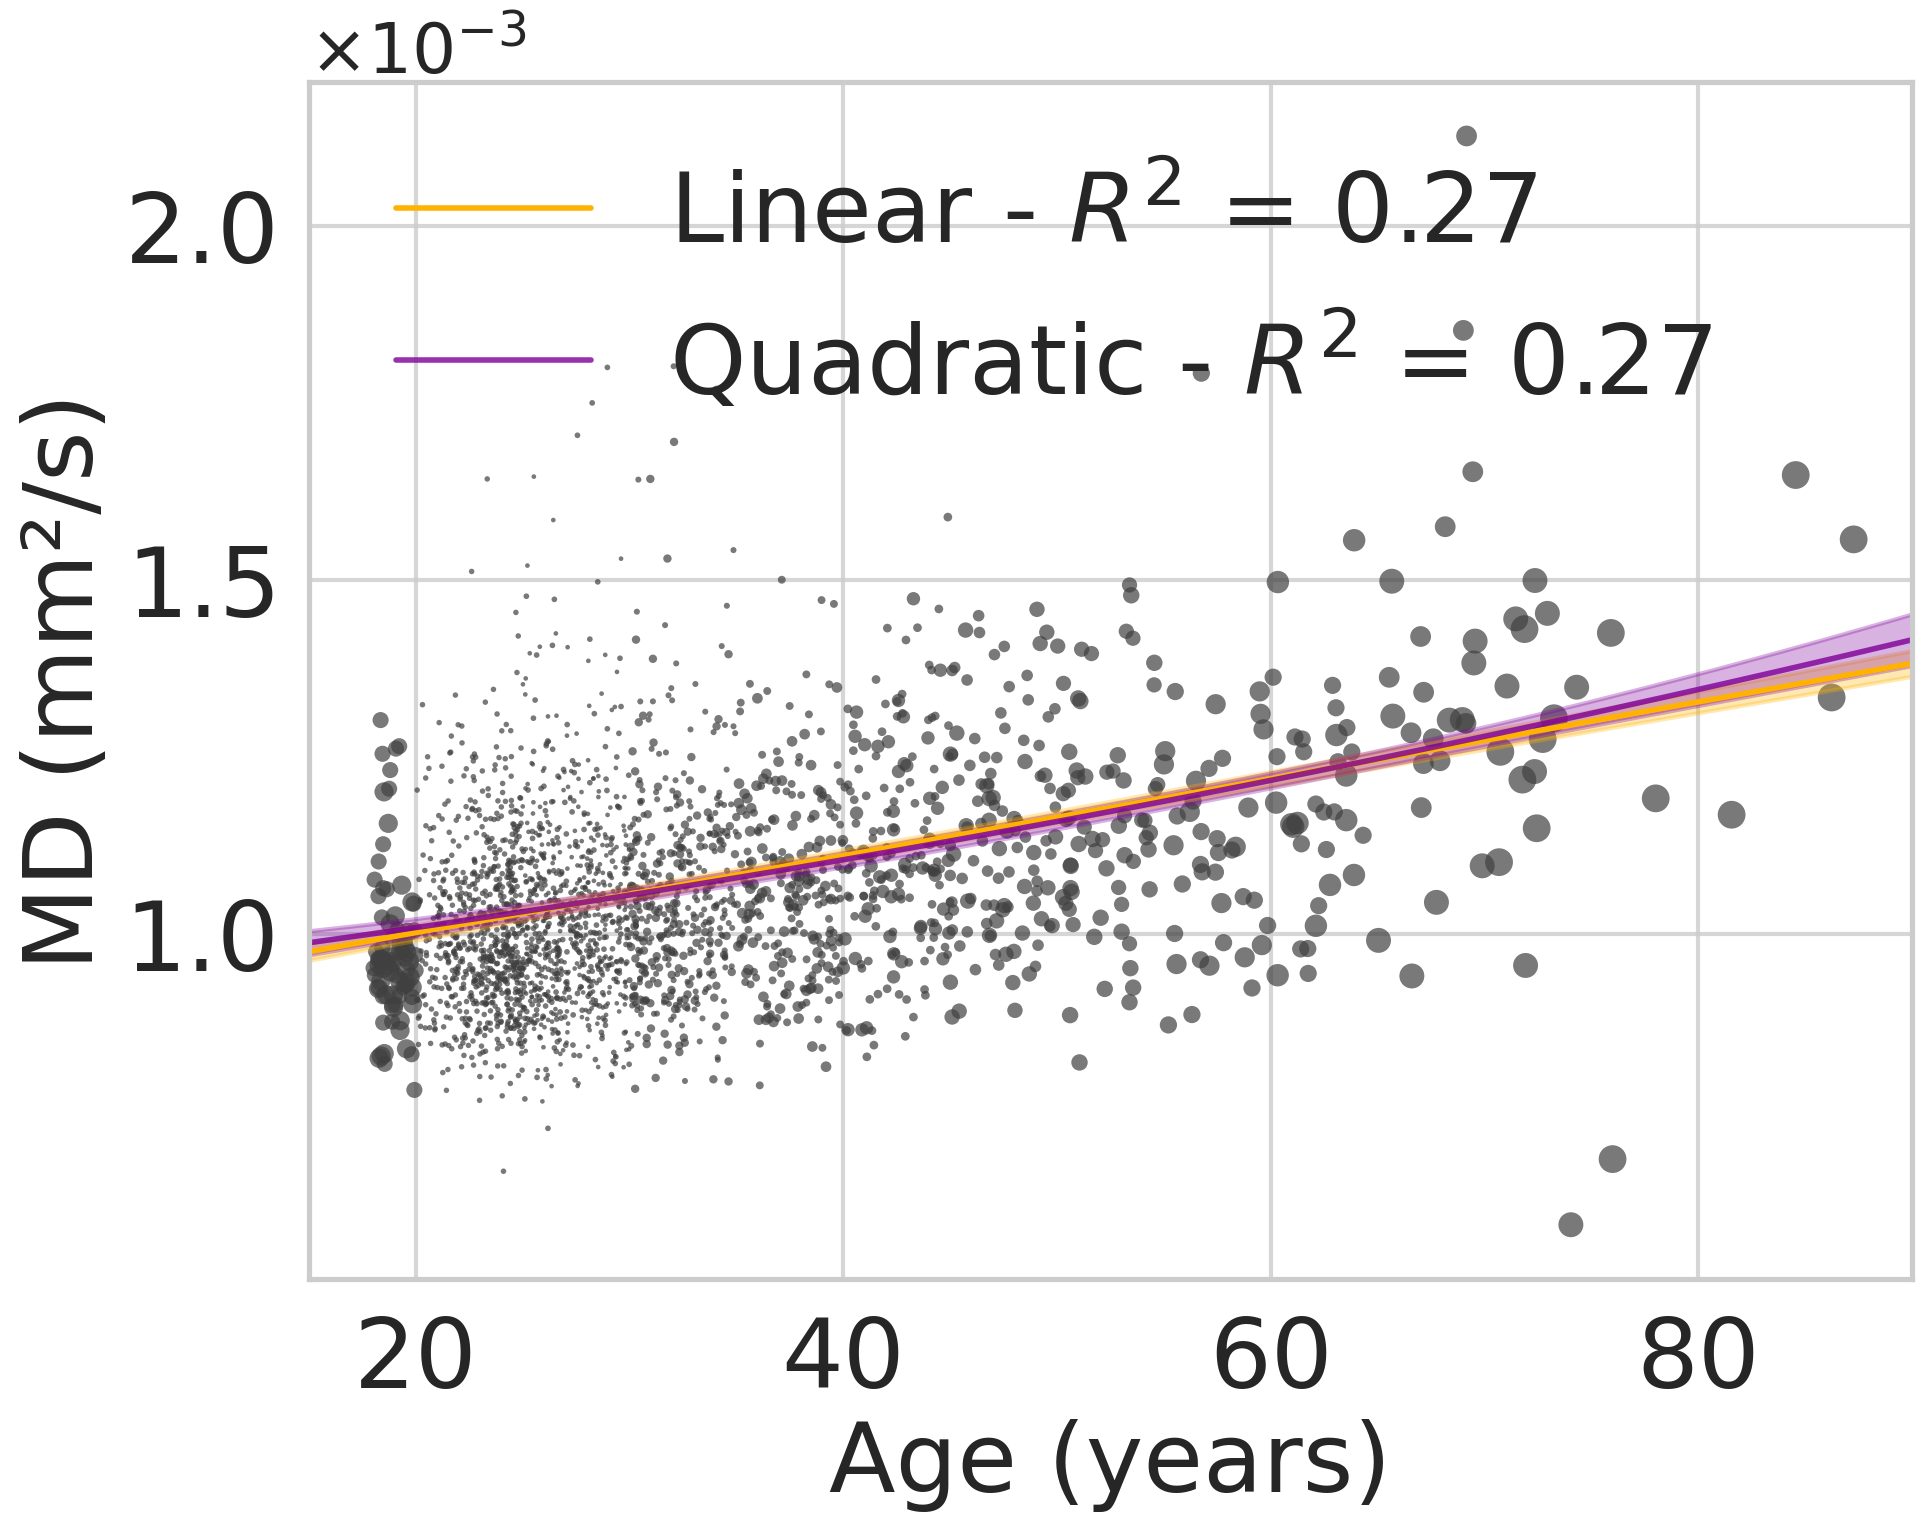

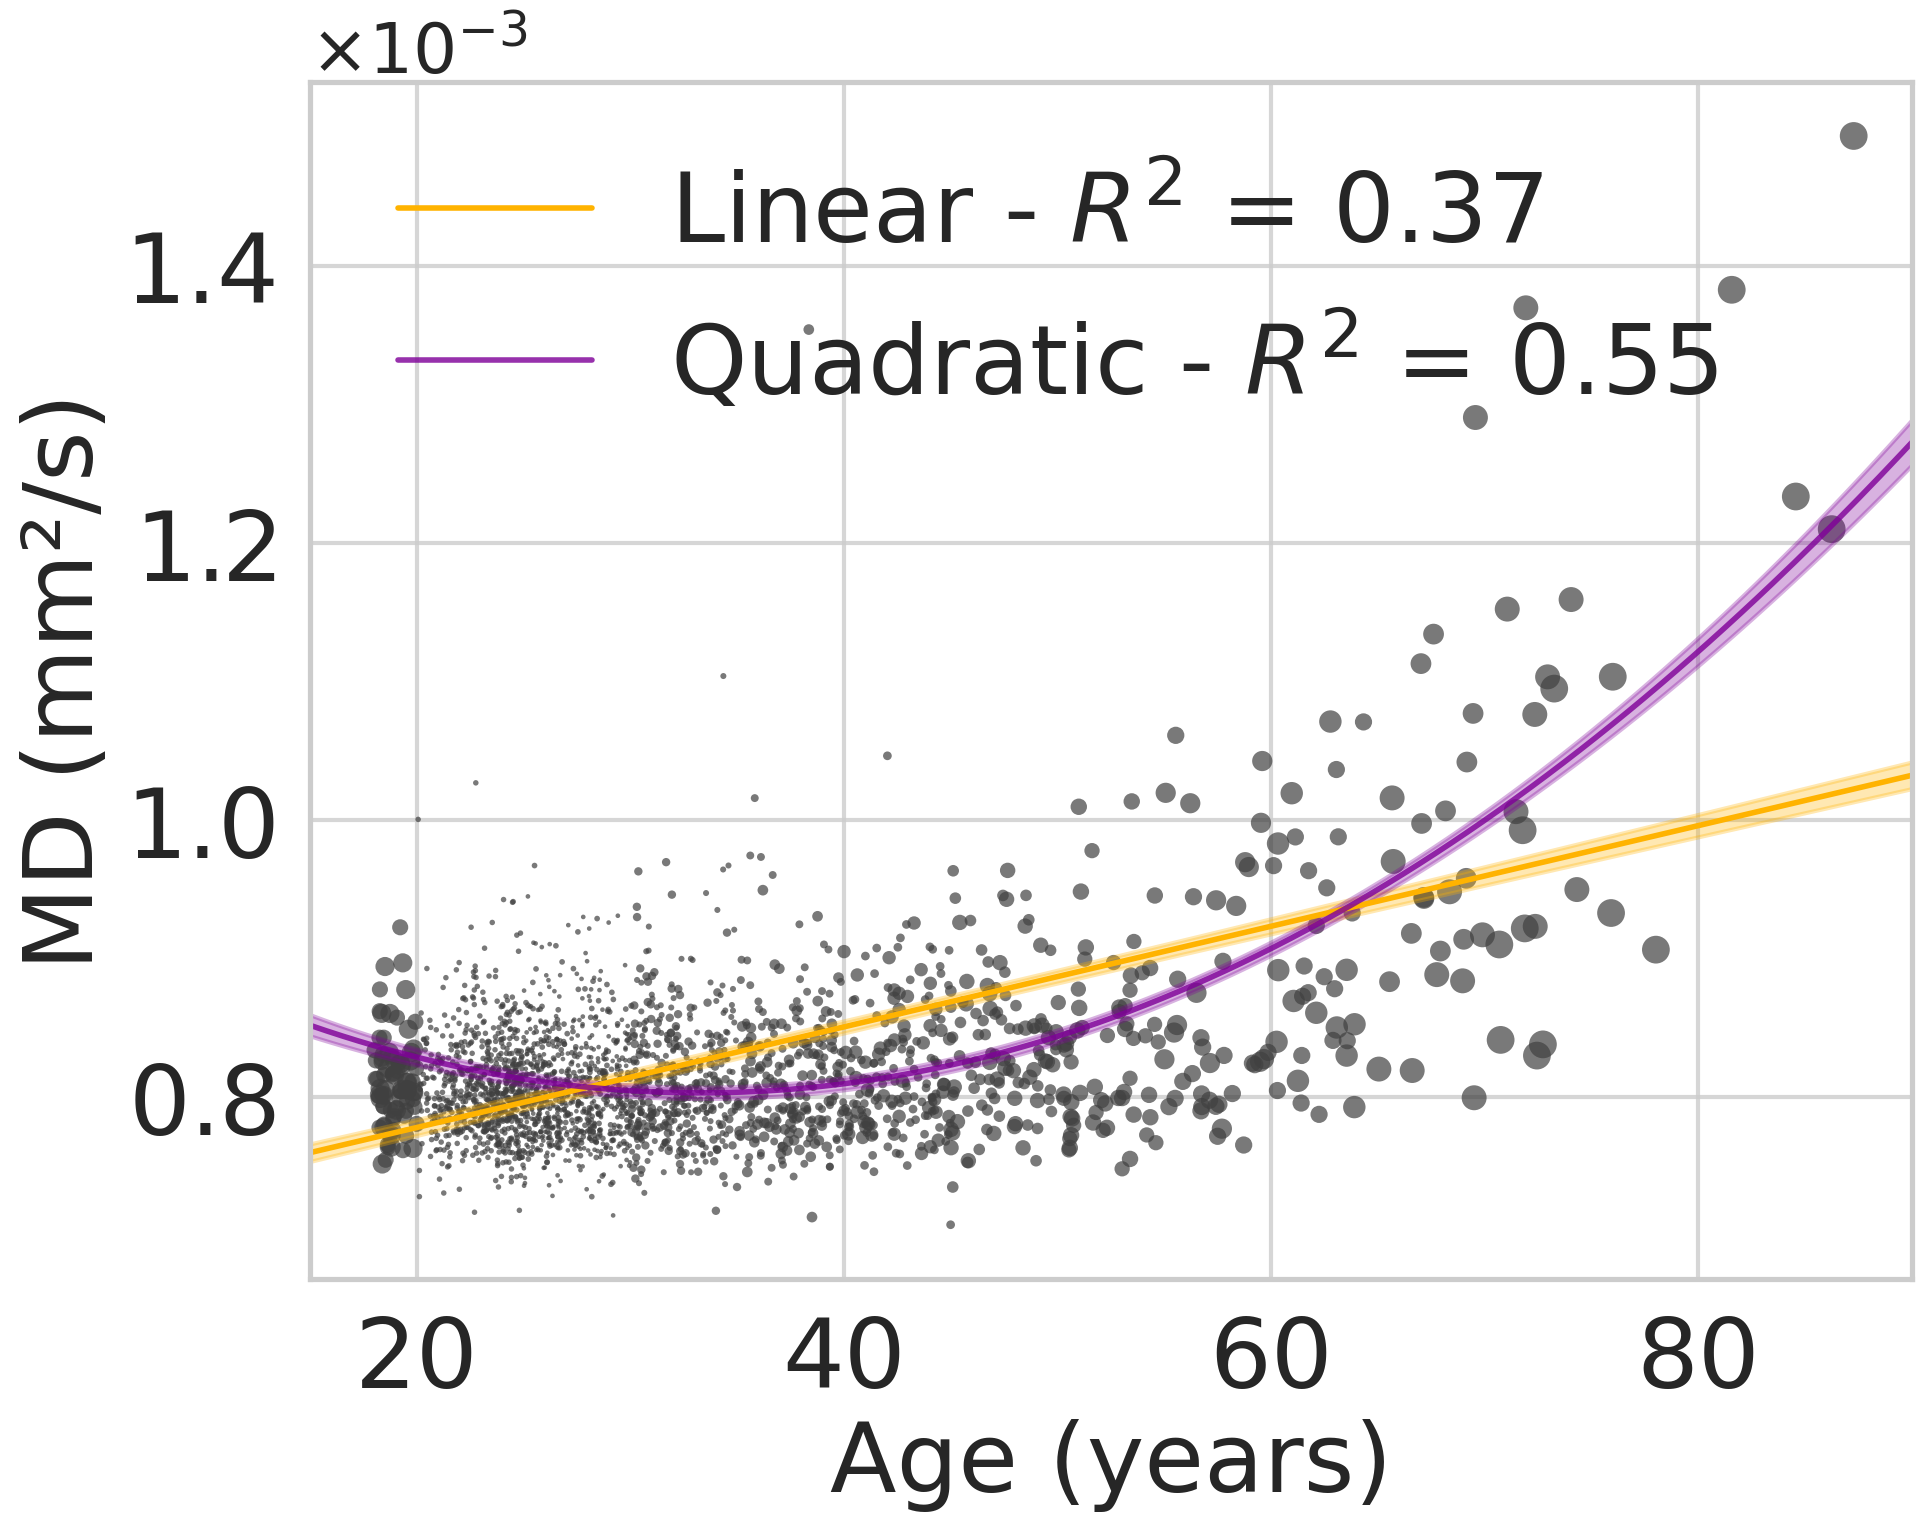

In [ ]:
age_min, age_max = 15, 90
age_grid = np.linspace(age_min, age_max, 300)
visual_age_grid = age_grid.copy()
age_mean = data["age_at_scan"].mean()


if CENTER_VARIABLES:
    age_grid = age_grid - age_mean

rois = [48, 405] if metric == "gm_vol" else [50, 234]

for i in rois:
    # lm = lin_w.loc[i, "model"]
    # qm = quad_w.loc[i, "model"]
    lm = models.linear.loc[i, "model"]
    qm = models.quadratic.loc[i, "model"]

    d = data[data[region_col] == parcels.loc[i, region_col]].copy()
    if CENTER_VARIABLES:
        d[age_col] = d["age_at_scan"] - age_mean
        if "tiv" in covariates:
            tiv_mean = data["tiv"].mean()
            d["tiv"] = d["tiv"] - tiv_mean
    # remove outliers
    # d = d[
    #     (d[metric_col] > d[metric_col].quantile(0.001))
    #     & (d[metric_col] < d[metric_col].quantile(0.999))
    # ]
    # d = d[(d[metric_col] > d[metric_col].quantile(0.001))]

    # ────────────────── Panel B: Predicted trajectory ± 95 % CI ──────────────

    mpl.rcParams.update({"axes.labelsize": 35, "ytick.labelsize": 25, "xtick.labelsize": 25})

    fig, ax = plt.subplots(figsize=(10, 8))

    # 3. Prediction frame

    # ── 3. Prediction grid ──────────────────────────────────────────────
    grid_df = pd.DataFrame({age_col: age_grid, "age_squared": age_grid**2})

    # add any covariates present in models (use median/mode)
    covs = [
        v
        for v in qm.model.exog_names
        if v not in ["Intercept", age_col, "age_squared", f"I({age_col} ** 2)"]
    ]
    for c in covs:
        if pd.api.types.is_numeric_dtype(data[c]):
            grid_df[c] = d[c].median()
        else:
            grid_df[c] = d[c].mode()[0]

    # 4. Get predictions & CI
    for tag, model in [("Linear", lm), ("Quadratic", qm)]:
        pr = model.get_prediction(grid_df)
        ci = pr.conf_int(alpha=0.05)
        grid_df[f"{tag}_fit"] = pr.predicted_mean
        grid_df[f"{tag}_lo"] = ci[:, 0]
        grid_df[f"{tag}_hi"] = ci[:, 1]

    # 5. Plot
    ax.clear()  # reuse the same axes handle

    # Background scatter (down-sample for speed / clarity)
    sizes = np.clip(d["weight"] * 10, 0, 100)
    sns.scatterplot(
        data=d,
        x="age_at_scan",
        y=metric_col,
        alpha=0.7,
        s=sizes,
        edgecolor="none",
        ax=ax,
        legend=False,
        color=COL_REF,
    )

    # # Fit lines & ribbons
    for tag, color, model in zip(["Linear", "Quadratic"], [COL_RAW, COL_WEIGHTED], [lm, qm]):
        # label = f"{tag} - $R^2$ = {model.rsquared:.2f}, AIC = {int(np.round(model.aic)):d}"
        label = f"{tag} - $R^2$ = {model.rsquared:.2f}"
        ax.plot(visual_age_grid, grid_df[f"{tag}_fit"], label=label, lw=2, color=color)
        ax.fill_between(
            visual_age_grid,
            grid_df[f"{tag}_lo"],
            grid_df[f"{tag}_hi"],
            color=color,
            alpha=0.3,
        )

    # add age star
    # stab_age = stab_df.loc[i, "age_star"]

    # if stab_age > 18:
    #     lab = f"Peak Structural Integrity (APSI) = {stab_age:.1f} years"
    # else:
    #     lab = f"Peak Structural Integrity (APSI) ≤ {stab_age:.1f} years"

    # ax.axvline(
    #     stab_age,
    #     color="green",
    #     linestyle="--",
    #     lw=3,
    #     label=lab,
    # )

    ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)
    if metric == "gm_vol":
        ylabel = "GM Volume (mm³)"
        # set y axis format to cm instead of mm
    else:
        ylabel = "MD (mm²/s)"

    ax.set(
        xlabel="Age (years)",
        ylabel=ylabel,
        xlim=(age_min, age_max),
    )

    # change tick size
    ax.tick_params(axis="both", which="major", labelsize=35)
    # title = "(A) GM Volume" if metric == "gm_vol" else "(B) Mean Diffusivity"
    # suptitle = example_rois.get(i, {}).get("name", f"Region {i}")

    # ax.set_title("Predicted trajectory (± 95 % CI)")
    # ax.set_title(title, fontsize=30, pad=20)
    ax.legend(frameon=False, fontsize=35, loc="upper left")

    # model_type = "quad" if use_quadratic else "linear"
    savefig_nice(
        fig,
        OUTPUT_DIR / f"fig2_{metric}_{i+1}.png",
        tight=True,
        dpi=300,
    )